### Visualization of the training progress

In [1]:
import re
import matplotlib.pyplot as plt

In [2]:
log_path = "/home/ul/ul_student/ul_raf24/project/Masterarbeit/my_gpt2/results/pretraining/log_model_30000_fineweb10B.out"

train_steps, train_loss = [], []
val_steps, val_loss = [], []
hella_steps, hella_acc = [], []

step_re = re.compile(r"^step\s+(\d+)\s+\|\s+loss:\s+([0-9.]+)")
val_re  = re.compile(r"^validation loss:\s+([0-9.]+)")
hella_re = re.compile(r"^HellaSwag accuracy:\s+\d+/\d+=([0-9.]+)")

last_step = None

with open(log_path, "r", errors="ignore") as f:
    for line in f:
        line = line.strip()

        m = step_re.match(line)
        if m:
            last_step = int(m.group(1))
            train_steps.append(last_step)
            train_loss.append(float(m.group(2)))
            continue

        m = val_re.match(line)
        if m and last_step is not None:
            val_steps.append(last_step)
            val_loss.append(float(m.group(1)))
            continue

        m = hella_re.match(line)
        if m and last_step is not None:
            hella_steps.append(last_step)
            hella_acc.append(float(m.group(1)))
            continue

print("train points:", len(train_steps))
print("val points:", len(val_steps))
print("hella points:", len(hella_steps))

train points: 31676
val points: 126
hella points: 126


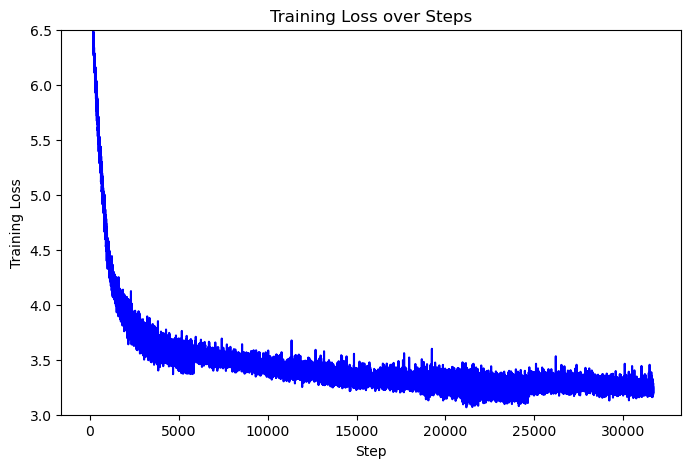

In [3]:
plt.figure(figsize=(8,5))
plt.plot(train_steps, train_loss, color = "blue")
plt.plot()
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("Training Loss over Steps")
plt.ylim(3,6.5)
plt.show()


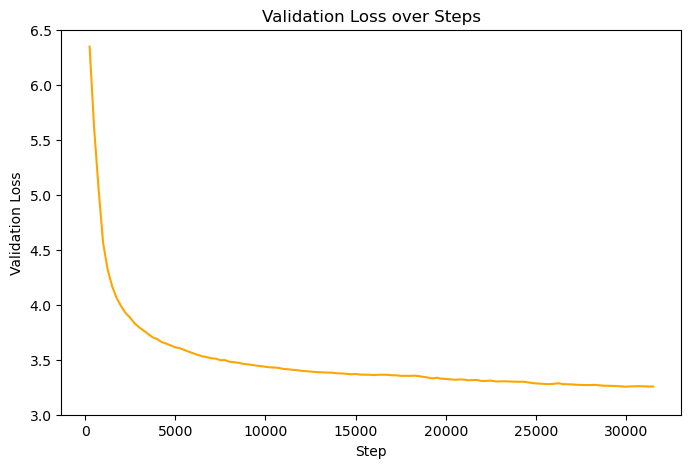

In [4]:
plt.figure(figsize=(8,5))
plt.plot(val_steps, val_loss, color = "orange")
plt.xlabel("Step")
plt.ylabel("Validation Loss")
plt.title("Validation Loss over Steps")
plt.ylim(3,6.5)
plt.show()



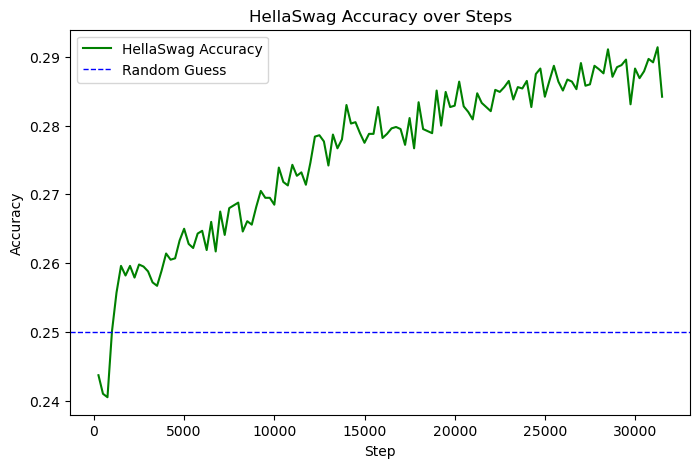

In [5]:
plt.figure(figsize=(8,5))
plt.plot(hella_steps, hella_acc, color = "green", label = "HellaSwag Accuracy")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.title("HellaSwag Accuracy over Steps")
plt.axhline(y=0.25, color="blue", linestyle="--", linewidth=1, label = "Random Guess")
plt.legend(loc="best")
plt.show()


### Use the Model

In [6]:
# load model and config
import sys
from pathlib import Path
import torch
import tiktoken
repo_root = Path("/home/ul/ul_student/ul_raf24/project/Masterarbeit")
sys.path.insert(0, str(repo_root))
from my_gpt2.source.model import GPT, GPTConfig

def generate(model, prompt, max_new_tokens=80, temperature=1.0, top_k=50, device="cuda"):
    enc = tiktoken.get_encoding("gpt2")
    x = torch.tensor(enc.encode(prompt), dtype=torch.long, device=device)[None, :]

    model.eval()
    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits, _ = model(x)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = -float("inf")
            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            x = torch.cat([x, next_id], dim=1)

    return enc.decode(x[0].tolist())

model_path = "/home/ul/ul_student/ul_raf24/project/Masterarbeit/my_gpt2/results/pretraining/model_30000_fineweb10B.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"

ckpt = torch.load(model_path, map_location=device)
config = ckpt["config"] if "config" in ckpt else GPTConfig(vocab_size=50304)

model = GPT(config).to(device)
model.load_state_dict(ckpt["model"], strict = True)
model.eval()

/scratch/ipykernel_842456/915306798.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)


GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50304, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='tanh')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50304, bias=False)
)

In [10]:
print(generate(model, "Hello, I'm a language model,", max_new_tokens=32, temperature=1, top_k=50, device=device))

Hello, I'm a language model, and I want to understand everything, and I find to understand what I'm trying to do. I wanted to learn how to use "Solve", the key
